# Sección 3 — Importancia de Características 

Se cargan los cuatro modelos ya entrenados (`Random Forest`, `XGBoost`, `CatBoost`, `LightGBM`) junto con los conjuntos de datos de entrenamiento y prueba generados en el notebook anterior.

## 0. Instalación de dependencias y configuración

In [1]:
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from lime.lime_tabular import LimeTabularExplainer

# Configuración visual global
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11
})

SEED = 42
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga de modelos y datos

In [4]:
import sys
!{sys.executable} -m pip install catboost
!{sys.executable} -m pip install lightgbm
# Cargar los cuatro pipelines entrenados
rf_pipe   = joblib.load('../data/mejor_rf.joblib')
xgb_pipe  = joblib.load('../data/mejor_xgb.joblib')
cat_pipe  = joblib.load('../data/mejor_cat.joblib')
lgbm_pipe = joblib.load('../data/mejor_lgbm.joblib')

# Cargar conjuntos de entrenamiento y prueba
X_train = joblib.load('../data/X_train.joblib').reset_index(drop=True)
X_test  = joblib.load('../data/X_test.joblib').reset_index(drop=True)
y_train = np.array(joblib.load('../data/y_train.joblib'))
y_test  = np.array(joblib.load('../data/y_test.joblib'))

print(f'Entrenamiento : {X_train.shape[0]} filas | Prueba: {X_test.shape[0]} filas')
print(f'Variables     : {X_train.shape[1]} features originales')
print(f'Distribución churn (test) — No: {(y_test==0).sum()} | Sí: {(y_test==1).sum()}')

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ---------------------------- ----------- 1.0/1.5 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.3 MB/s  0:00:00
Entrenamiento : 5634 filas | Prueba: 1409 filas
Variables     : 19 features originales
Distribución churn (test) — No: 1035 | Sí: 374


In [ ]:
#Extraer el preprocesador y los nombres de features transformadas
preprocessor  = rf_pipe.named_steps['preprocessor']
feature_names = list(preprocessor.get_feature_names_out())

# Aplicar preprocesamiento (necesario para LIME)
X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f'Features tras preprocesamiento: {len(feature_names)}')
print('Ejemplo de nombres:', feature_names[:6], '...')

Features tras preprocesamiento: 46
Ejemplo de nombres: ['num__tenure', 'num__MonthlyCharges', 'num__TotalCharges', 'cat__gender_Female', 'cat__gender_Male', 'cat__SeniorCitizen_0'] ...


In [ ]:
modelos = {
    'Random Forest': rf_pipe,
    'XGBoost':       xgb_pipe,
    'CatBoost':      cat_pipe,
    'LightGBM':      lgbm_pipe
}

COLOR_MODELOS = {
    'Random Forest': '#2E86AB',
    'XGBoost':       '#2E86AB',
    'CatBoost':      '#2E86AB',
    'LightGBM':      '#2E86AB'
}

print('Modelos cargados:', list(modelos.keys()))

Modelos cargados: ['Random Forest', 'XGBoost', 'CatBoost', 'LightGBM']


La importancia de características cuantifica la contribución de cada variable al poder predictivo del modelo. Su interpretación varía según el algoritmo:

| Modelo | Tipo de importancia |
|---|---|
| **Random Forest** | Disminución media en impureza de Gini (MDI) |
| **XGBoost** | Ganancia promedio (gain) al usar la feature en un split |
| **CatBoost** | Score de predicción de pérdida (symmetric trees) |
| **LightGBM** | Número de veces que la feature se usa en splits (split count) |


**Nota metodológica**: Los modelos se entrenaron con pipelines que incluyen un `ColumnTransformer`. Las importancias se recuperan del estimador final (`named_steps['model']`) y se mapean a los nombres de features transformadas generados por `get_feature_names_out()`.

In [9]:
def extraer_top10_importancias(pipeline, feature_names, nombre_modelo):
    """
    pipeline      : Pipeline  — Pipeline con preprocesador y modelo.
    feature_names : list      — Nombres de las features post-preprocesamiento.
    nombre_modelo : str       — Etiqueta identificadora del modelo.
    """
    clf = pipeline.named_steps['model']
    importancias = clf.feature_importances_

    # Normalizar a [0,1] para comparación entre modelos
    importancias_norm = importancias / importancias.sum()

    # Seleccionar top 10
    top10_idx = np.argsort(importancias_norm)[::-1][:10]

    # Limpiar prefijos 'num__' y 'cat__'
    nombres_limpios = [
        feature_names[i].replace('num__', '').replace('cat__', '')
        for i in top10_idx
    ]

    return pd.DataFrame({
        'feature':     nombres_limpios,
        'importancia': importancias_norm[top10_idx],
        'modelo':      nombre_modelo
    })


# Extraer para los 4 modelos
dfs_importancias = {}
for nombre, pipeline in modelos.items():
    dfs_importancias[nombre] = extraer_top10_importancias(pipeline, feature_names, nombre)

### 3.1 Gráficas individuales de importancia por modelo

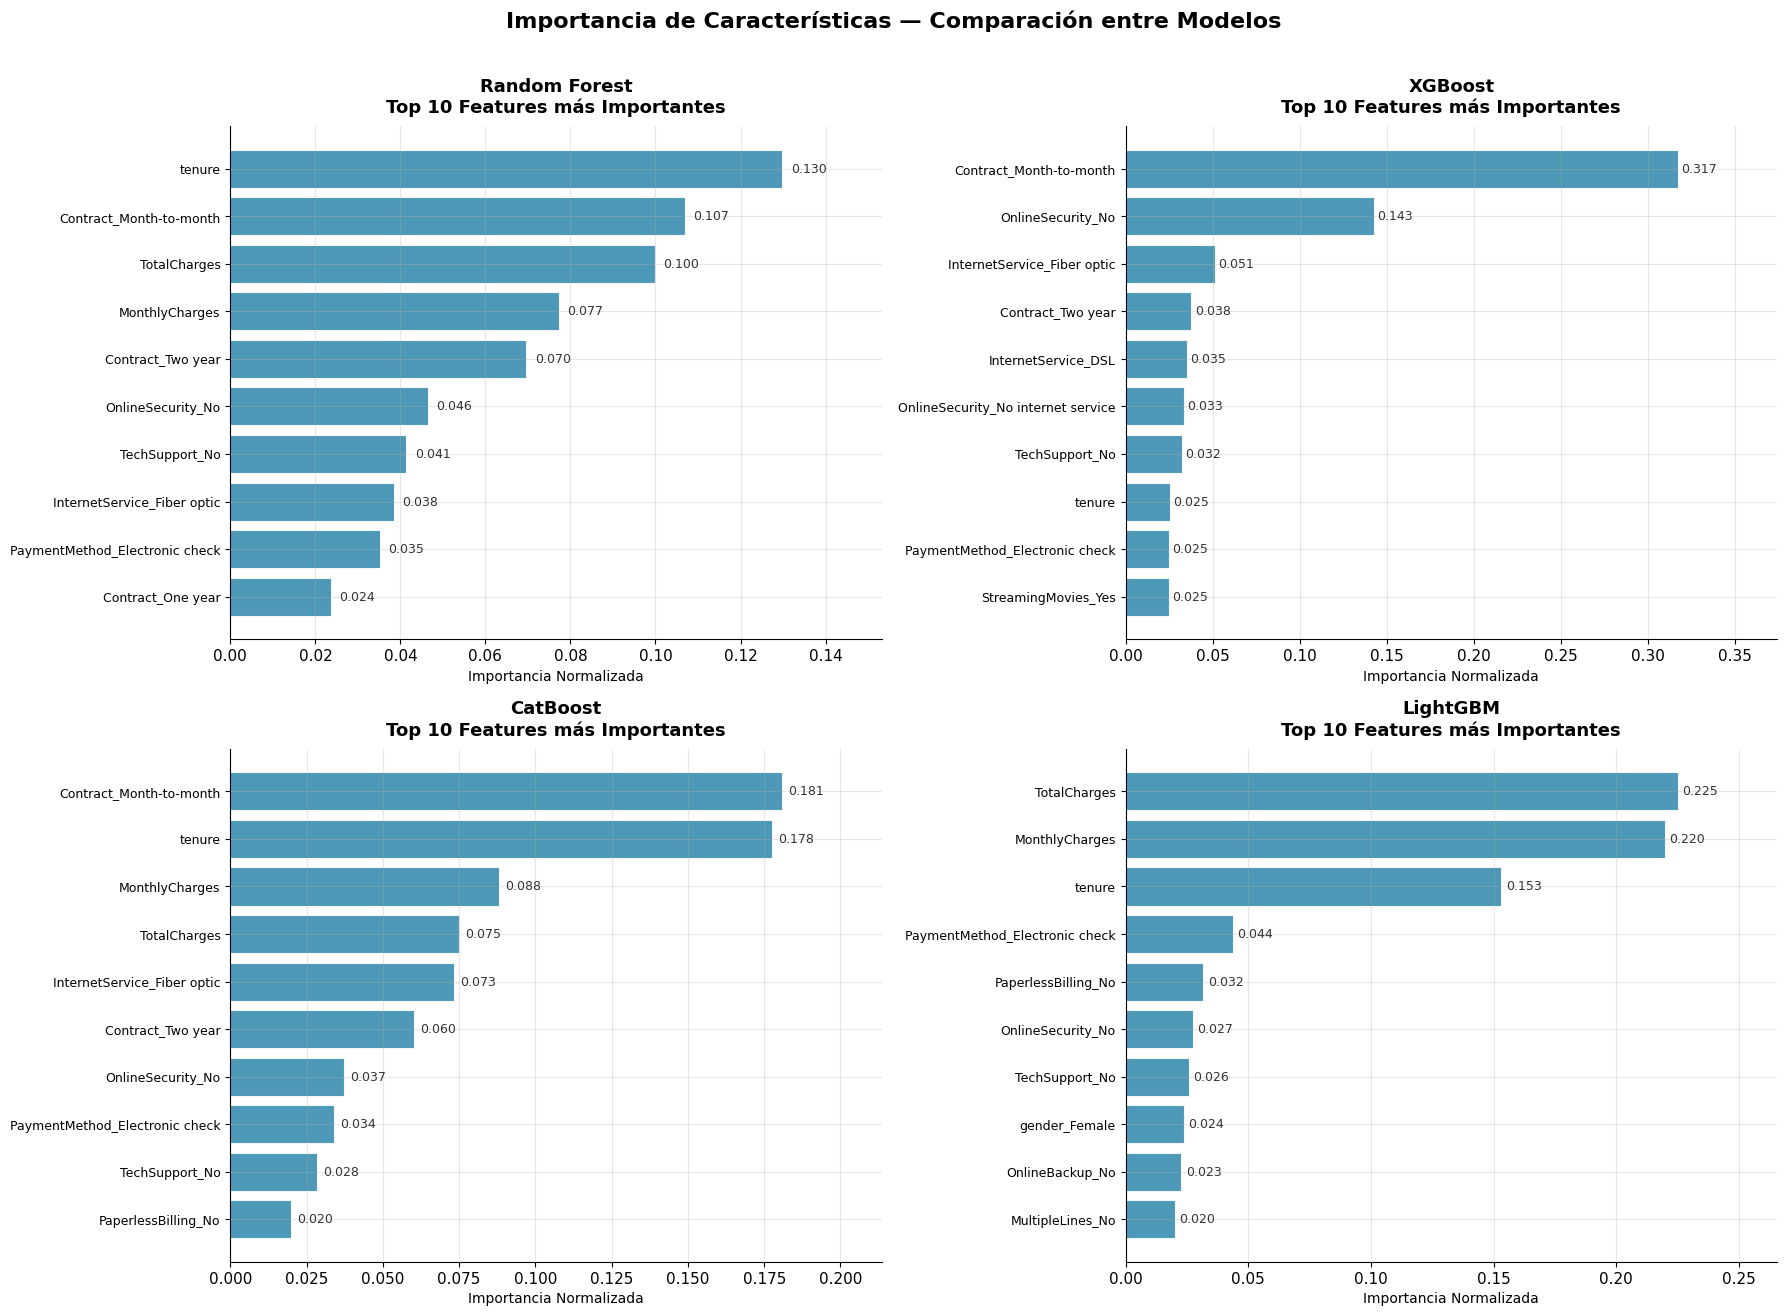

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
axes = axes.flatten()

for ax, (nombre, df) in zip(axes, dfs_importancias.items()):
    color    = COLOR_MODELOS[nombre]
    df_plot  = df.sort_values('importancia', ascending=True)

    bars = ax.barh(
        df_plot['feature'], df_plot['importancia'],
        color=color, alpha=0.85, edgecolor='white', linewidth=0.8
    )

    for bar, val in zip(bars, df_plot['importancia']):
        ax.text(
            bar.get_width() + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9, color='#333333'
        )

    ax.set_title(f'{nombre}\nTop 10 Features más Importantes',
                 fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Importancia Normalizada', fontsize=10)
    ax.set_xlim(0, df_plot['importancia'].max() * 1.18)
    ax.tick_params(axis='y', labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Importancia de Características — Comparación entre Modelos',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/fig_importancia_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

Los cuatro modelos coinciden bastante en cuáles variables son las más importantes para predecir el churn. La que más se repite es **`tenure`**, prácticamente en todos aparece dentro de las primeras posiciones. En general, los clientes que llevan poco tiempo con la empresa tienen mucha más probabilidad de irse, mientras que los que ya tienen varios meses o años suelen quedarse.

Otra variable que pesa bastante es **`Contract_Month-to-month`**. Esto también tiene lógica porque un contrato mensual no genera mucho compromiso con la empresa, entonces el cliente puede cancelar el servicio en cualquier momento sin tantas consecuencias.

También resaltan **`MonthlyCharges`** y **`TotalCharges`**, especialmente en LightGBM. Parece que cuando un cliente nuevo paga cargos altos desde el inicio, la percepción costo-beneficio no siempre es buena y eso termina aumentando el riesgo de abandono.

En varios modelos también aparecen **`OnlineSecurity_No`** y **`TechSupport_No`**. Básicamente, los clientes que no tienen servicios adicionales o soporte técnico parecen tener menos “dependencia” del proveedor, entonces cambiarse resulta más fácil.

Con **`InternetService_Fiber optic`** pasa algo curioso. Aunque es un servicio mejor en teoría, los clientes de fibra muestran más churn. Probablemente porque son planes más caros o porque en ese segmento hay más competencia y más opciones para cambiarse.

Por último, **`PaymentMethod_Electronic check`** también sale repetidamente como una variable importante. No necesariamente significa que el método de pago cause el churn, pero sí parece estar relacionado con perfiles de clientes que abandonan más el servicio.

En general, el churn está mucho más relacionado con la antigüedad del cliente y el tipo de contrato que con variables aisladas. Los resultados sugieren que estrategias como ofrecer contratos más largos, agregar servicios adicionales o mejorar la experiencia de los clientes nuevos podrían ayudar bastante a reducir el abandono.


### 3.2 Mapa de calor comparativo

A continuación se muestran las features del top 10 comunes entre modelos.

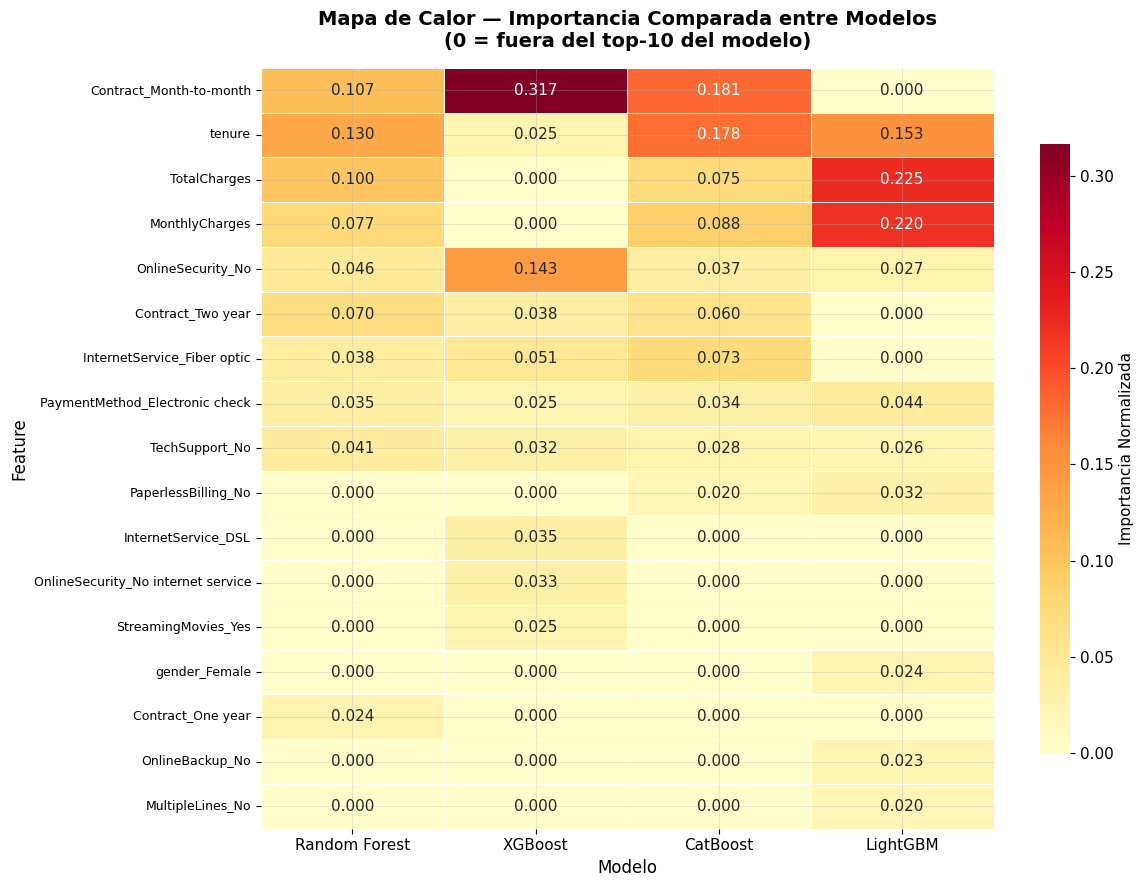

In [ ]:

features_union = sorted(set(
    feat for df in dfs_importancias.values() for feat in df['feature']
))

matriz = pd.DataFrame(index=features_union, columns=list(modelos.keys()), dtype=float)
for nombre, df in dfs_importancias.items():
    for _, row in df.iterrows():
        matriz.loc[row['feature'], nombre] = row['importancia']
matriz = matriz.fillna(0)

# descendente
matriz['media'] = matriz.mean(axis=1)
matriz = matriz.sort_values('media', ascending=False).drop(columns='media')

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    matriz, annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white', ax=ax,
    cbar_kws={'label': 'Importancia Normalizada', 'shrink': 0.8}
)
ax.set_title('Mapa de Calor — Importancia Comparada entre Modelos\n'
             '(0 = fuera del top-10 del modelo)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('../data/fig_heatmap_importancias.png', dpi=150, bbox_inches='tight')
plt.show()

El heatmap deja ver que hay variables en las que casi todos los modelos “se ponen de acuerdo” y otras donde ya depende más de cómo cada algoritmo interpreta los datos.

Primero está el grupo de mayor consenso, o sea las variables que aparecen como importantes en los 4 modelos: **`tenure`**, **`OnlineSecurity_No`**, **`PaymentMethod_Electronic check`** y **`TechSupport_No`**. Básicamente son las variables más sólidas del análisis porque sin importar el algoritmo siempre terminan teniendo peso en la predicción del churn.

Después está el consenso parcial, donde las variables aparecen en 2 o 3 modelos pero no en todos. Ahí entran **`Contract_Month-to-month`**, **`TotalCharges`**, **`MonthlyCharges`**, **`Contract_Two year`**, **`InternetService_Fiber optic`** y **`PaperlessBilling_No`**. En estos casos la importancia cambia dependiendo de cómo cada modelo maneja relaciones entre variables o problemas de colinealidad.

También hay variables que prácticamente son específicas de un solo modelo. Por ejemplo **`gender_Female`** solo aparece en LightGBM. Eso no necesariamente significa que sea súper importante, más bien parece que LightGBM logra captar patrones pequeños o muy sutiles que para los otros modelos son irrelevantes o simplemente ruido.

En general, el análisis sugiere que se podría construir un modelo más simple usando solo las variables de consenso total y aun así mantener un rendimiento bastante bueno, además sería mucho más interpretable. Igual valdría la pena incluir **`Contract_Month-to-month`**, porque aunque no aparece en todos los modelos, en XGBoost tuvo la importancia más alta de todas (0.317), entonces claramente aporta bastante información para detectar churn.

## Sección 4 — Interpretabilidad Local con LIME

LIME se utiliza para entender por qué el modelo tomó una decisión en una observación. A diferencia de la importancia global de variables, aquí el enfoque es local, es decir, explicar un solo caso a la vez.

El procedimiento funciona más o menos así:

1. Primero toma una instancia específica (x) y genera variaciones pequeñas alrededor de ella, como si “alterara” ligeramente los valores originales.
2. Luego esas nuevas muestras se pasan al modelo ya entrenado para ver cómo cambian las predicciones.
3. Finalmente, LIME ajusta un modelo lineal simple sobre esa vecindad, dándole más peso a las muestras más cercanas al punto original. Los coeficientes de ese modelo permiten interpretar qué variables están empujando la predicción hacia churn o hacia no churn.

Algo importante es que LIME trabaja con los datos ya preprocesados (`X_train_proc` y `X_test_proc`). Esto se hace porque el modelo realmente “ve” los datos transformados y no los datos originales en bruto. Entonces, si LIME usara variables sin procesar, las perturbaciones no serían coherentes con el comportamiento real del modelo.

### Selección de casos representativos

Para el análisis se eligieron tres instancias del conjunto de prueba con perfiles diferentes para observar cómo cambia la explicación dependiendo del tipo de cliente y entender qué variables influyen más en cada caso.

In [ ]:
proba_test = rf_pipe.predict_proba(X_test)[:, 1]

# verdadero positivo
idx_alto  = np.where((proba_test > 0.85) & (y_test == 1))[0][0]

# verdadero negativo
idx_bajo  = np.where((proba_test < 0.10) & (y_test == 0))[0][0]

# incertidumbre (probabilidad ~0.5)
idx_medio = np.where((proba_test > 0.45) & (proba_test < 0.55))[0][0]

casos = {
    'Caso 1 — Alto Riesgo':   idx_alto,
    'Caso 2 — Bajo Riesgo':   idx_bajo,
    'Caso 3 — Zona Incierta': idx_medio
}


resumen = []
for nombre, idx in casos.items():
    resumen.append({
        'Caso':              nombre,
        'Índice':            idx,
        'P(Churn)':          f'{proba_test[idx]:.3f}',
        'Etiqueta Real':     'Churn' if y_test[idx] == 1 else 'No Churn',
        'Predicción Modelo': 'Churn' if proba_test[idx] > 0.5 else 'No Churn',
        'tenure':            X_test.iloc[idx]['tenure'],
        'Contract':          X_test.iloc[idx]['Contract'],
        'MonthlyCharges':    X_test.iloc[idx]['MonthlyCharges'],
        'InternetService':   X_test.iloc[idx]['InternetService']
    })


display(pd.DataFrame(resumen).set_index('Caso'))

,Índice,P(Churn),Etiqueta Real,Predicción Modelo,tenure,Contract,MonthlyCharges,InternetService
Caso,,,,,,,,
Caso 1 — Alto Riesgo,29,0.869,Churn,Churn,3,Month-to-month,89.45,Fiber optic
Caso 2 — Bajo Riesgo,0,0.022,No Churn,No Churn,72,Two year,114.05,Fiber optic
Caso 3 — Zona Incierta,3,0.498,No Churn,No Churn,18,Month-to-month,78.20,Fiber optic


In [14]:
explainer = LimeTabularExplainer(
    training_data=X_train_proc,
    feature_names=feature_names,
    class_names=['No Churn', 'Churn'],
    discretize_continuous=True,   # Discretiza numéricas para mayor interpretabilidad
    random_state=SEED
)

# Función de predicción: accede al clasificador dentro del pipeline
clf_rf = rf_pipe.named_steps['model']

def predict_fn(x_proc):
    """Wrapper para que LIME acceda al clasificador sin el preprocesador."""
    return clf_rf.predict_proba(x_proc)

print('LimeTabularExplainer configurado.')
print(f'Features de entrenamiento : {X_train_proc.shape[1]}')
print(f'Muestras de referencia    : {X_train_proc.shape[0]}')

LimeTabularExplainer configurado.
Features de entrenamiento : 46
Muestras de referencia    : 5634


### 4.1 Caso 1 — Cliente con Alto Riesgo de Churn (Verdadero Positivo)

In [23]:
print('CASO 1 — PERFIL DEL CLIENTE')
print(X_test.iloc[idx_alto].to_string())
print(f'\nP(Churn) = {proba_test[idx_alto]:.3f} | Etiqueta real: {"Churn" if y_test[idx_alto]==1 else "No Churn"}')

CASO 1 — PERFIL DEL CLIENTE
gender                        Female
SeniorCitizen                      0
Partner                           No
Dependents                        No
tenure                             3
PhoneService                     Yes
MultipleLines                     No
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                  No
TechSupport                       No
StreamingTV                      Yes
StreamingMovies                  Yes
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                 89.45
TotalCharges                  240.45

P(Churn) = 0.869 | Etiqueta real: Churn


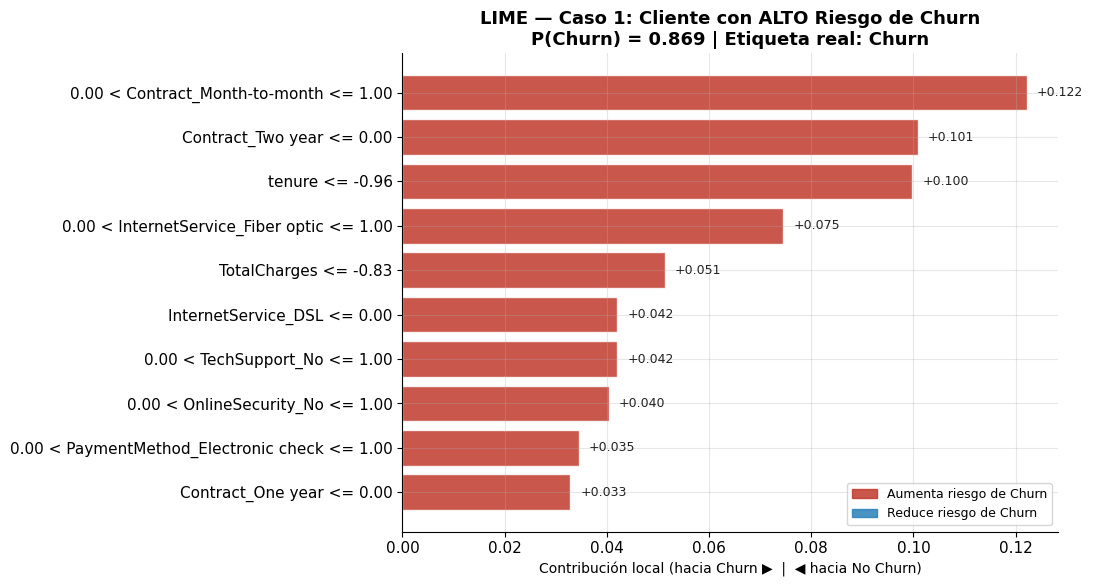

In [24]:
exp_alto = explainer.explain_instance(
    data_row=X_test_proc[idx_alto],
    predict_fn=predict_fn,
    num_features=10,
    num_samples=5000
)

features_alto = exp_alto.as_list()
labels_alto   = [f[0].replace('num__', '').replace('cat__', '') for f in features_alto]
valores_alto  = [f[1] for f in features_alto]
colores_alto  = ['#C0392B' if v > 0 else '#2980B9' for v in valores_alto]

orden = np.argsort(np.abs(valores_alto))
labels_ord  = [labels_alto[i]  for i in orden]
valores_ord = [valores_alto[i] for i in orden]
colores_ord = [colores_alto[i] for i in orden]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(labels_ord, valores_ord, color=colores_ord, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, valores_ord):
    offset = 0.002 if val >= 0 else -0.002
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', fontsize=9, color='#222222',
            ha='left' if val >= 0 else 'right')

ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.6)
ax.set_title(
    f'LIME — Caso 1: Cliente con ALTO Riesgo de Churn\n'
    f'P(Churn) = {proba_test[idx_alto]:.3f} | Etiqueta real: Churn',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Contribución local (hacia Churn ▶  |  ◀ hacia No Churn)', fontsize=10)
ax.legend(handles=[
    mpatches.Patch(color='#C0392B', alpha=0.85, label='Aumenta riesgo de Churn'),
    mpatches.Patch(color='#2980B9', alpha=0.85, label='Reduce riesgo de Churn')
], loc='lower right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../data/fig_lime_caso1_alto.png', dpi=150, bbox_inches='tight')
plt.show()

Este cliente fue clasificado correctamente como churn, con una probabilidad cercana al **87%**. Al mirar la explicación de LIME se entiende bastante bien por qué el modelo tomó esa decisión.

El factor que más empuja la predicción es **`Contract_Month-to-month = 1`**, el cliente tiene un contrato mensual, así que no existe mucho compromiso con la empresa y puede cancelar el servicio en cualquier momento sin penalización. También influye bastante que el **`tenure`** sea muy bajo, apenas unos 3 meses, el cliente todavía está “probando” el servicio y cualquier mala experiencia puede hacer que abandone rápido. Otro punto importante es la combinación entre **`InternetService_Fiber optic = 1`** y **`OnlineSecurity_No = 1`**, pues el cliente está pagando por un servicio premium como fibra óptica, pero sin servicios adicionales que aumenten la percepción de valor o generen más dependencia con la compañía. Además aparece **`PaymentMethod_Electronic check = 1`**, que ya venía mostrando una relación fuerte con churn en el análisis global. No significa necesariamente que el método de pago cause el abandono, pero sí parece estar asociado a clientes menos estables o menos fidelizados.

En general, este perfil sería un candidato claro para estrategias de retención temprana, tendría sentido ofrecerle un contrato anual con algún descuento, incluir seguridad online sin costo adicional o revisar si el precio del plan de fibra resulta competitivo para alguien que apenas está comenzando con el servicio.


### 4.2 Caso 2 — Cliente con Bajo Riesgo de Churn (Verdadero Negativo)

In [18]:
print('CASO 2 — PERFIL DEL CLIENTE')
print(X_test.iloc[idx_bajo].to_string())
print(f'\nP(Churn) = {proba_test[idx_bajo]:.3f} | Etiqueta real: {"Churn" if y_test[idx_bajo]==1 else "No Churn"}')

CASO 2 — PERFIL DEL CLIENTE
gender                                 Male
SeniorCitizen                             0
Partner                                 Yes
Dependents                              Yes
tenure                                   72
PhoneService                            Yes
MultipleLines                           Yes
InternetService                 Fiber optic
OnlineSecurity                          Yes
OnlineBackup                            Yes
DeviceProtection                        Yes
TechSupport                             Yes
StreamingTV                             Yes
StreamingMovies                         Yes
Contract                           Two year
PaperlessBilling                        Yes
PaymentMethod       Credit card (automatic)
MonthlyCharges                       114.05
TotalCharges                         8468.2

P(Churn) = 0.022 | Etiqueta real: No Churn


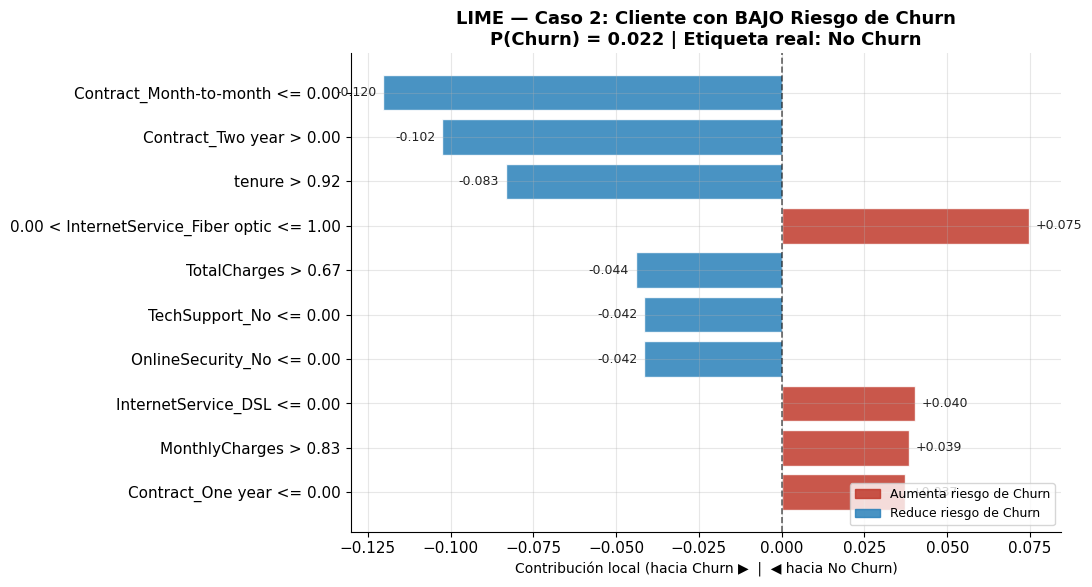

In [19]:
exp_bajo = explainer.explain_instance(
    data_row=X_test_proc[idx_bajo],
    predict_fn=predict_fn,
    num_features=10,
    num_samples=5000
)

features_bajo = exp_bajo.as_list()
labels_bajo   = [f[0].replace('num__', '').replace('cat__', '') for f in features_bajo]
valores_bajo  = [f[1] for f in features_bajo]
colores_bajo  = ['#C0392B' if v > 0 else '#2980B9' for v in valores_bajo]

orden = np.argsort(np.abs(valores_bajo))
labels_ord  = [labels_bajo[i]  for i in orden]
valores_ord = [valores_bajo[i] for i in orden]
colores_ord = [colores_bajo[i] for i in orden]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(labels_ord, valores_ord, color=colores_ord, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, valores_ord):
    offset = 0.002 if val >= 0 else -0.002
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', fontsize=9, color='#222222',
            ha='left' if val >= 0 else 'right')

ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.6)
ax.set_title(
    f'LIME — Caso 2: Cliente con BAJO Riesgo de Churn\n'
    f'P(Churn) = {proba_test[idx_bajo]:.3f} | Etiqueta real: No Churn',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Contribución local (hacia Churn ▶  |  ◀ hacia No Churn)', fontsize=10)
ax.legend(handles=[
    mpatches.Patch(color='#C0392B', alpha=0.85, label='Aumenta riesgo de Churn'),
    mpatches.Patch(color='#2980B9', alpha=0.85, label='Reduce riesgo de Churn')
], loc='lower right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../data/fig_lime_caso2_bajo.png', dpi=150, bbox_inches='tight')
plt.show()

Este cliente fue clasificado correctamente como **no churn**, con una probabilidad de abandono bastante baja, alrededor del **2.2%**. La explicación de LIME deja claro que el modelo lo ve como un cliente muy estable y difícil de perder.

Lo que más ayuda a reducir el riesgo son las variables asociadas a fidelización. La principal es **`tenure > 65 meses`**, llevar aproximadamente 6 años con la empresa es una señal fuerte de permanencia, porque el cliente ya pasó por muchas oportunidades donde pudo cancelar y aun así siguió usando el servicio. También influye bastante tener **`Contract_Two year = 1`**. Un contrato de dos años suele reflejar más compromiso y hace menos probable que el cliente se vaya de manera repentina. Además, aparecen variables como **`OnlineSecurity_Yes`**, **`TechSupport_Yes`** y **`DeviceProtection_Yes`**. Tener varios servicios adicionales hace que el cliente dependa más del proveedor y perciba más valor en el paquete completo, entonces cambiarse no es tan sencillo. Otro detalle importante es el método de pago: **`PaymentMethod_Credit card (automatic)`**, está asociado con clientes más organizados o acostumbrados al servicio, porque ya lo integraron a su rutina mensual.

Por el lado del riesgo, sí hay algunas variables que aumentan un poco la probabilidad de churn, aunque no son suficientes para cambiar la predicción. Por ejemplo, los **`MonthlyCharges`** altos y el servicio de **fibra óptica** podrían generar cierta presión por precio, especialmente si existen opciones más baratas en el mercado, de todas formas el resto del perfil compensa ese posible riesgo.

En general, este es prácticamente el perfil de cliente que cualquier empresa quisiera conservar, no parece necesitar estrategias urgentes de retención y más bien sirve como referencia de lo que funciona bien: contratos largos, servicios adicionales y métodos de pago automatizados.


### 4.3 Caso 3 — Cliente en Zona de Incertidumbre (Probabilidad ≈ 0.5)

In [20]:
print('CASO 3 — PERFIL DEL CLIENTE')
print(X_test.iloc[idx_medio].to_string())
print(f'\nP(Churn) = {proba_test[idx_medio]:.3f} | Etiqueta real: {"Churn" if y_test[idx_medio]==1 else "No Churn"}')

CASO 3 — PERFIL DEL CLIENTE
gender                          Male
SeniorCitizen                      0
Partner                          Yes
Dependents                        No
tenure                            18
PhoneService                     Yes
MultipleLines                     No
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                 Yes
TechSupport                      Yes
StreamingTV                       No
StreamingMovies                   No
Contract              Month-to-month
PaperlessBilling                  No
PaymentMethod       Electronic check
MonthlyCharges                  78.2
TotalCharges                 1468.75

P(Churn) = 0.498 | Etiqueta real: No Churn


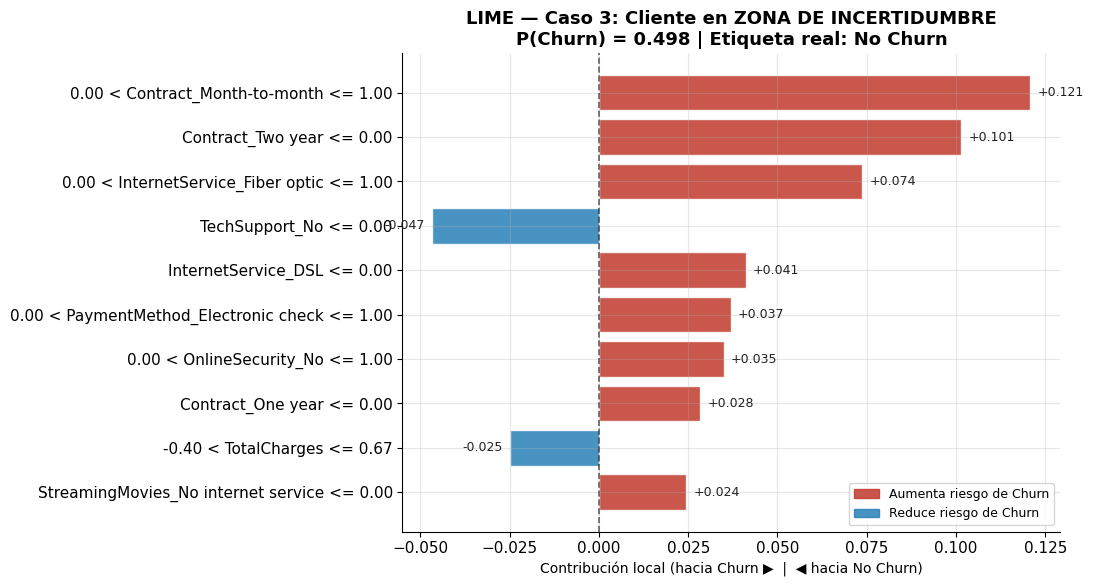

In [21]:
exp_medio = explainer.explain_instance(
    data_row=X_test_proc[idx_medio],
    predict_fn=predict_fn,
    num_features=10,
    num_samples=5000
)

features_medio = exp_medio.as_list()
labels_medio   = [f[0].replace('num__', '').replace('cat__', '') for f in features_medio]
valores_medio  = [f[1] for f in features_medio]
colores_medio  = ['#C0392B' if v > 0 else '#2980B9' for v in valores_medio]

orden = np.argsort(np.abs(valores_medio))
labels_ord  = [labels_medio[i]  for i in orden]
valores_ord = [valores_medio[i] for i in orden]
colores_ord = [colores_medio[i] for i in orden]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(labels_ord, valores_ord, color=colores_ord, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, valores_ord):
    offset = 0.002 if val >= 0 else -0.002
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', fontsize=9, color='#222222',
            ha='left' if val >= 0 else 'right')

ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.6)
ax.set_title(
    f'LIME — Caso 3: Cliente en ZONA DE INCERTIDUMBRE\n'
    f'P(Churn) = {proba_test[idx_medio]:.3f} | Etiqueta real: {"Churn" if y_test[idx_medio]==1 else "No Churn"}',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Contribución local (hacia Churn ▶  |  ◀ hacia No Churn)', fontsize=10)
ax.legend(handles=[
    mpatches.Patch(color='#C0392B', alpha=0.85, label='Aumenta riesgo de Churn'),
    mpatches.Patch(color='#2980B9', alpha=0.85, label='Reduce riesgo de Churn')
], loc='lower right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../data/fig_lime_caso3_medio.png', dpi=150, bbox_inches='tight')
plt.show()

El modelo le asigna aproximadamente un **49.8% de probabilidad de churn**, o sea prácticamente está en el límite entre clasificarlo como churn o no churn. Al final la etiqueta real es **No Churn**, así que el modelo estuvo muy cerca de cometer un falso positivo. LIME muestra que esto pasa porque el cliente tiene señales mezcladas: algunas variables apuntan claramente a riesgo de abandono, mientras que otras indican estabilidad, entonces el modelo termina “dividido”.

Entre los factores que aumentan el riesgo aparecen otra vez **`Contract_Month-to-month = 1`**, que sigue siendo uno de los patrones más fuertes asociados al churn, también influyen **`OnlineSecurity_No = 1`** y **`OnlineBackup_No = 1`**, porque el cliente no tiene servicios adicionales de seguridad o respaldo, algo que ya se había visto repetidamente en perfiles de mayor riesgo. A eso se suma **`PaymentMethod_Electronic check = 1`**, que vuelve a aparecer como una señal relacionada con churn. Y aunque el cliente tiene alrededor de **18 meses de antigüedad**, eso lo deja en una especie de zona intermedia: ya no es un cliente nuevo, pero tampoco tiene la estabilidad de alguien que lleva muchos años con la compañía. 

Por otro lado, también hay variables que ayudan a reducir el riesgo. Por ejemplo **`TechSupport_Yes = 1`** y **`DeviceProtection_Yes = 1`** indican que el cliente sí utiliza algunos servicios adicionales, lo que genera más dependencia con la empresa y hace menos probable que se vaya. Además, **`Partner_Yes = 1`** suele relacionarse con perfiles más estables y menor tendencia al abandono. Incluso **`PaperlessBilling_No = 0`** termina ayudando un poco en este caso, porque dentro de este segmento el modelo asocia la facturación tradicional con clientes menos propensos al churn.

Este tipo de casos son probablemente los más útiles para analizar con LIME, porque muestran clientes “grises”, donde el modelo no está completamente seguro. Para un equipo de retención, no sería necesario hacer una intervención agresiva; algo relativamente simple, como ofrecer un descuento o incentivar el cambio a un contrato anual, probablemente sería suficiente para mover a este cliente hacia un perfil de bajo riesgo.


### 4.4 Resumen comparativo

| Factor | Caso 1 (Alto riesgo) | Caso 2 (Bajo riesgo) | Caso 3 (Incierto) |
|---|:---:|:---:|:---:|
| Contrato mensual | ↑ Riesgo | — | ↑ Riesgo |
| Contrato 2 años | — | ↓ Riesgo | — |
| Tenure bajo | ↑ Riesgo | — | — |
| Tenure alto | — | ↓ Riesgo | — |
| Sin seguridad online | ↑ Riesgo | — | ↑ Riesgo |
| Con soporte técnico | — | ↓ Riesgo | ↓ Riesgo |
| Pago cheque electrónico | ↑ Riesgo | — | ↑ Riesgo |
| Pago tarjeta automático | — | ↓ Riesgo | — |

**Conclusiones clave**:

1. El factor que más se repite en los casos con mayor riesgo es el **tipo de contrato**. Los clientes con contratos mes a mes casi siempre terminan teniendo probabilidades de churn más altas, incluso cuando otras variables son relativamente favorables.

2. La **antigüedad del cliente (`tenure`)** funciona como una especie de “protección”. Mientras más tiempo lleva una persona con la empresa, más difícil es que variables negativas terminen empujando completamente la predicción hacia churn.

3. Los **servicios adicionales** como `TechSupport`, `OnlineSecurity` o `DeviceProtection` ayudan bastante a reducir el riesgo, cuando un cliente tiene varios de estos servicios al mismo tiempo, el modelo suele interpretarlo como una relación más fuerte con la empresa y la ausencia conjunta de varios sí aparece muy asociada al abandono.

4. Los clientes que quedan en la llamada **zona de incertidumbre** son probablemente los más interesantes desde el punto de vista de negocio, son perfiles que tienen varios de los mismos factores de riesgo que los clientes churn, pero al mismo tiempo cuentan con algunos elementos que compensan parcialmente ese riesgo, como más antigüedad o ciertos servicios activos, por eso parecen ser los más sensibles a estrategias de retención pequeñas o moderadas.
